In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from numpy.random import Generator
from numpy.typing import ArrayLike
from pident.common.distributions import Constant, TruncLognorm, UnivarDist
from pident.lib.liu_et_al_model import (
    liu_et_al_no_nN_model,
)
from pident.synthetic_data.dist_samplers import independent_sampler
from pident.synthetic_data.obs_noise import add_noise, proportional_normal_error_model
from pident.synthetic_data.obs_samplers import Timeseries, subsample_trajectories

## parameter distributions

This is based on table S6 in the supplement.
I'm assuming everything is lognormal and I'm going to be conservative with
`mlx_omega` (standard deviation of the log of the r.v.)

Couldn't find `nTA0` in the supplement anywhere,
but based on the files in `data/liu_et_al_data/Simulation of responses`
it seems like it should be set to 0.

In [3]:
CR_param_dists: dict[str, UnivarDist] = {
    "rP": Constant(0.069),
    "rTA": TruncLognorm(median=1.62, mlx_omega=0.000001),
    "lTA": TruncLognorm(median=0.12, mlx_omega=0.000001),
    "lTN": TruncLognorm(median=3e-5, mlx_omega=0.000001),
    "nC": TruncLognorm(median=2939.1, mlx_omega=0.000001),
    "e": Constant(22.72),
    "KP": TruncLognorm(median=5891.5, mlx_omega=0.000001),
    "Kr": TruncLognorm(median=637.64, mlx_omega=0.000001),
    "KA": TruncLognorm(median=1808.0, mlx_omega=0.000001),
    "kA": Constant(0.65),
}

CR_init_val_dists: dict[str, UnivarDist] = {
    "nP": Constant(2200.24),
    "nTA": Constant(0.0),
    "nTN": TruncLognorm(median=16.5, mlx_omega=0.000001),
}

CR_dists = (CR_param_dists, CR_init_val_dists)

NR_param_dists: dict[str, UnivarDist] = {
    "rP": Constant(0.080),
    "rTA": TruncLognorm(median=0.99, mlx_omega=0.000001),
    "lTA": TruncLognorm(median=0.55, mlx_omega=0.000001),
    "lTN": TruncLognorm(median=9.2e-4, mlx_omega=0.000001),
    "nC": TruncLognorm(median=6101.58, mlx_omega=0.000001),
    "e": TruncLognorm(median=6.58, mlx_omega=0.000001),
    "KP": TruncLognorm(median=7067.07, mlx_omega=0.000001),
    "Kr": TruncLognorm(median=3431.65, mlx_omega=0.000001),
    "KA": TruncLognorm(median=5.2e-3, mlx_omega=0.000001),
    "kA": Constant(0.31),
}

NR_init_val_dists: dict[str, UnivarDist] = {
    "nP": Constant(589.676),
    "nTA": Constant(0.0),
    "nTN": Constant(71.45),
}

NR_dists = (NR_param_dists, NR_init_val_dists)

CD19_pos_relapse_param_dists: dict[str, UnivarDist] = {
    "rP": Constant(0.21),
    "rTA": Constant(0.99),
    "lTA": TruncLognorm(median=0.12, mlx_omega=0.000001),
    "lTN": TruncLognorm(median=6e-7, mlx_omega=0.000001),
    "nC": Constant(19877.4),
    "e": Constant(20.31),
    "KP": Constant(1050.19),
    "Kr": Constant(1983.64),
    "KA": TruncLognorm(median=54.68, mlx_omega=0.000001),
    "kA": Constant(0.44),
}

CD19_pos_relapse_init_val_dists: dict[str, UnivarDist] = {
    "nP": Constant(1764.25),
    "nTA": Constant(0.0),
    "nTN": TruncLognorm(median=12.26, mlx_omega=0.000001),
}

CD19_pos_relapse_dists = (CD19_pos_relapse_param_dists, CD19_pos_relapse_init_val_dists)

In [4]:
def dists_to_independent_samples(
    dist_dict: dict[str, UnivarDist], rng: Generator, n_samples: int
) -> list[dict[str, float]]:
    """
    Independently sample from each distribution in `dist_dict` `n_samples` times,
    returning a list of `n_samples` dicts from keys in `dist_dict` to sampled values
    """
    keys = dist_dict.keys()
    dists = [dist_dict[key] for key in keys]
    sampler = independent_sampler(dists)
    sampled_val_lists = [sampler(rng) for _ in range(n_samples)]
    return [
        {k: v for k, v in zip(keys, vals)} for vals in sampled_val_lists  # type: ignore
    ]

CR


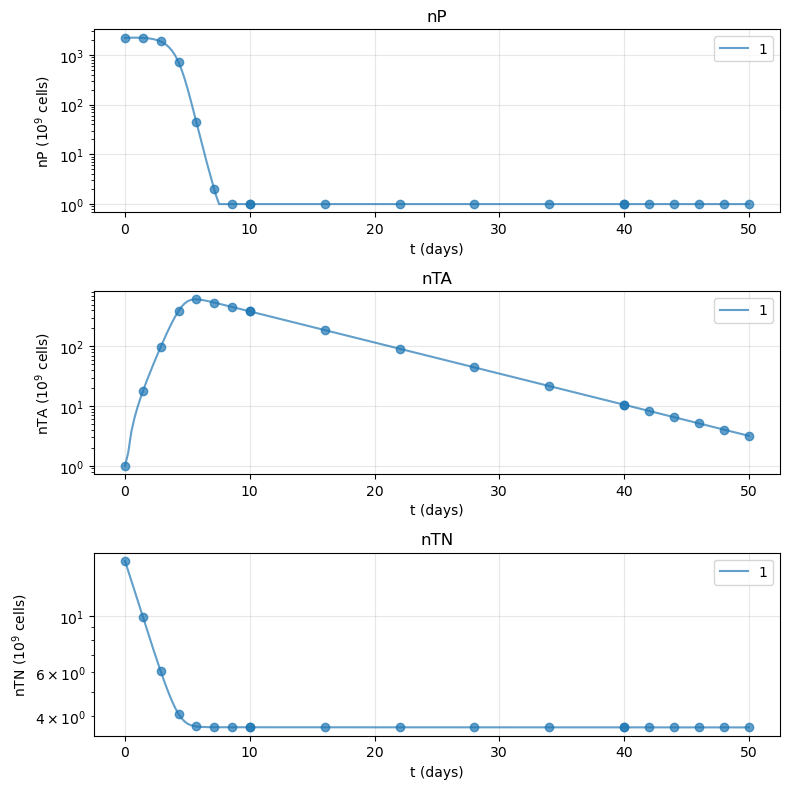

NR


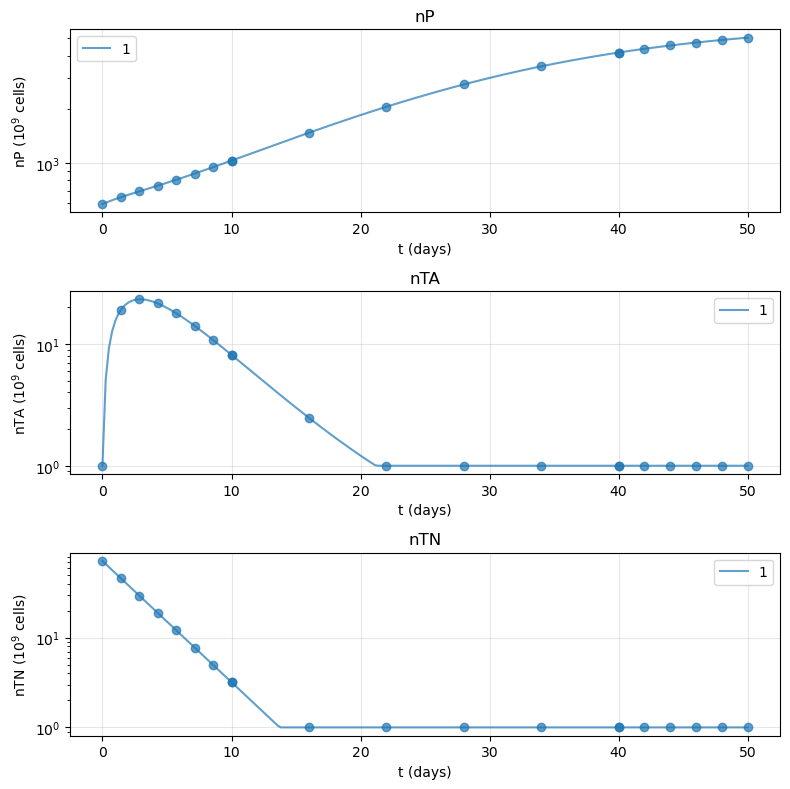

CD19+ relapse


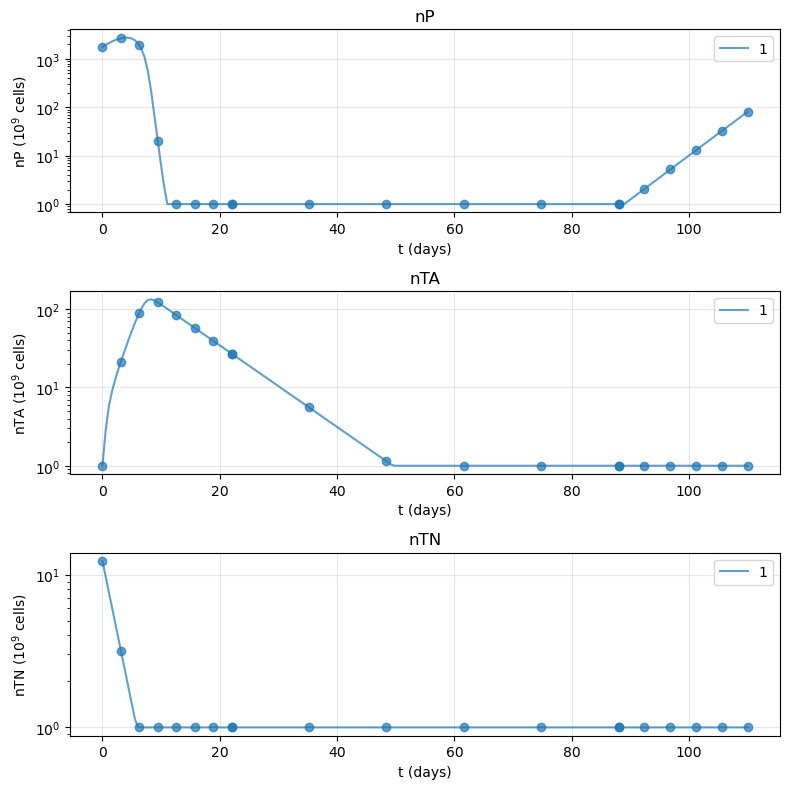

In [ ]:
rng = np.random.default_rng(seed=11113)
trajectories_per_patient: dict[str, dict[str, Timeseries]] = {}
for response, (param_dists, obs_var_init_val_dists), end_day in zip(
    ["CR", "NR", "CD19+ relapse"],
    [CR_dists, NR_dists, CD19_pos_relapse_dists],
    [50, 50, 110],
):
    print(response)
    n_patients = 1
    start_day = 0

    # generate ground truths
    param_val_dicts = dists_to_independent_samples(param_dists, rng, n_patients)
    init_val_dicts = dists_to_independent_samples(
        obs_var_init_val_dists, rng, n_patients
    )
    ground_truths = [
        liu_et_al_no_nN_model.get_ground_truth(
            param_val_dict, init_val_dict, start_day, end_day
        )
        for param_val_dict, init_val_dict in zip(param_val_dicts, init_val_dicts)
    ]

    # subsample trajectories
    def _lerp(start: float, end: float, frac: float) -> float:
        return start * (1 - frac) + end * frac

    cutpts = (_lerp(start_day, end_day, 0.2), _lerp(start_day, end_day, 0.8))
    obs_times = np.concat(
        (
            np.linspace(start_day, cutpts[0], 8),
            np.linspace(cutpts[0], cutpts[1], 6),
            np.linspace(cutpts[1], end_day, 6),
        )
    )
    scheds: dict[str, ArrayLike] = {
        obs_var: obs_times for obs_var in liu_et_al_no_nN_model.obs_var_names
    }
    trajectories_all = [
        subsample_trajectories(ground_truth, scheds) for ground_truth in ground_truths
    ]

    # add noise
    noise_level = 0.0
    error_models = {
        "nP": proportional_normal_error_model(noise_level, 1e-6),
        "nTA": proportional_normal_error_model(noise_level, 1e-6),
        "nTN": proportional_normal_error_model(noise_level, 1e-6),
        "nN": proportional_normal_error_model(noise_level, 1e-6),
    }
    noisy_trajectories_all = [
        add_noise(trajectories, error_models, rng) for trajectories in trajectories_all
    ]
    t = np.linspace(start_day, end_day, 200)

    fig, axs = plt.subplots(len(liu_et_al_no_nN_model.obs_var_names), 1, figsize=(8, 8))
    axs = axs.flatten()

    # update trajectories per patient for csv
    trajectories_for_mlx: dict[str, Timeseries] = {}
    model_trajectories = noisy_trajectories_all[0]
    log_tumor_counts = np.log10(np.maximum(1e9 * model_trajectories["nP"]["y"], 1))  # type: ignore
    trajectories_for_mlx["T"] = {
        "t": model_trajectories["nP"]["t"],
        "y": log_tumor_counts,
    }
    log_cartcell_counts = np.log10(
        np.maximum(
            1e9 * (model_trajectories["nTA"]["y"] + model_trajectories["nTN"]["y"]),  # type: ignore
            1,
        )
    )
    trajectories_for_mlx["C"] = {
        "t": model_trajectories["nP"]["t"],
        "y": log_cartcell_counts,
    }
    trajectories_per_patient[response] = trajectories_for_mlx

    # Using tab20 colormap which has high contrast colors
    colors = plt.cm.tab20(np.linspace(0, 1, n_patients))  # type: ignore

    for i, (ground_truth, noisy_trajectories, color) in enumerate(
        zip(ground_truths, noisy_trajectories_all, colors)
    ):
        for obs_var, ax in zip(liu_et_al_no_nN_model.obs_var_names, axs):
            ax.semilogy(
                t,
                np.maximum(ground_truth(t)[obs_var], 1),
                label=f"{i+1}",
                color=color,
                alpha=0.7,
            )
            noisy_traj = noisy_trajectories[obs_var]
            ax.semilogy(
                noisy_traj["t"],
                np.maximum(noisy_traj["y"], 1),
                "o",
                color=color,
                alpha=0.7,
            )
            ax.set_title(f"{obs_var} ({noise_level=})")
            ax.set_title(f"{obs_var}")
            ax.set_xlabel("t (days)")
            ax.set_ylabel(f"{obs_var} ($10^9$ cells)")
            ax.legend()
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()